# E4 — Heterogeneous treatment effects (CATE): does advertising work equally well for everyone?

**Experiment contract**

| | |
|---|---|
| **Question** | Estimate the conditional average treatment effect $\widehat{\tau}(x) = \widehat{E}[Y(1) - Y(0) \mid X = x]$ for the visit outcome, rank users by predicted uplift, and test whether the top of that ranking shows a *detectably larger observed randomized-arm effect* than the pooled ITT (+1.034pp, E3). |
| **Business decision** | Whether a targeting policy based on estimated uplift is worth competitive development vs. broad-cast advertising — i.e., is the effect concentrated enough in identifiable users to justify a targeted-send arm in an experiment. |
| **Population / split** | 15M; deterministic row_hash splits. **Train** (hash%1000<700, 10M rows) for fitting; **validation** (700–849, 2M, both arms) for all evaluation in this notebook. |
| **Treatment usage** | Both learners use the treatment assignment column as **model input / within-CATE-construction only** (S-learner toggles the treatment feature; T-learner conditions on arm). It is *never* used as a standalone targeting feature, and prediction is always on feature-only rows. |
| **Method (deliberately small model count)** | **S-learner:** one HistGradientBoostingClassifier(max_iter=300, lr=0.05, early_stopping=False, random_state=42) fit on all train rows with features f0..f11 + treatment; $\hat\tau_S(x) = \hat p(x, t{=}1) - \hat p(x, t{=}0)$. **T-learner:** two same-hyperparameter HistGB models, m1 on treated-train rows, m0 on control-train rows; $\hat\tau_T(x) = m_1(x) - m_0(x)$. |
| **Outcome** | `visit` (primary). `conversion` not modeled (0.29% base — arm-wise contrasts per slice unstable at this stage; a transfer check under a stronger model is deferred). |
| **Metrics** | Qini curve + Qini coefficient and AUUC via `scikit-uplift` (open-source, battle-tested; standard definitions documented in the next cell). Top-decile observed effect in randomized arms with bootstrap 95% CI (1,000 resamples, seed 42). Spearman rank correlation of S- vs T-learner CATE on a 1M-row deterministic subsample; top-decile selection overlap. Pooled decile calibration table (predicted vs. observed effect within each decile). |
| **Assumptions** | Treatment randomized (E1: balanced covariates, max abs SMD 0.049) → arm-wise contrast within any *pre-registered-style* score-defined slice estimates that slice's true average effect. Models are response-surface approximations, not guaranteed consistent estimators of $\tau$; conclusions are about *ranking utility*, not about individual-level causality. |
| **Limitations** | (1) S-/T-learners are *practical* CATE proxies — no guarantee of pointwise consistency. (2) Benchmark non-uniform subsampling (E3) distorts absolute rates/effects; relative ranking statements are the safe units. (3) With a two-arm randomized experiment and no individual-level potential-outcome observation, individual $\tau$ is fundamentally not point-identifiable — we can only test whether *group* effects differ across score slices; language stays at "users with high/negative **estimated** CATE", never "individuals with negative treatment effect". (4) Treatment/outcome timing and feature semantics are anonymized (benchmark). |

## Metric definitions (exact)

Let $n$ be the number of validation rows, sorted by a CATE score in **descending** order (ties: control rows first within equal scores — the convention verified against sklift's own implementation by the raw-curve cross-check below). For prefix size $q \in \{1,\dots,n\}$ let $Y_t(q), Y_c(q)$ = cumulative treated/control outcome (visit) sums, and $N_t(q), N_c(q)$ = cumulative treated/control counts.

- **Qini curve**: $qini(q) = Y_t(q) - Y_c(q)\cdot\frac{N_t(q)}{N_c(q)}$  — incremental outcomes "attributable to treatment" within the first $q$ users, benchmarked against scaling the untreated counterfactual by the arm size ratio. sklift additionally subtracts a **random-ranking baseline** curve and normalizes by the perfect-ranking optimum Qini curve; `qini_auc_score` is therefore scale-free with 0 ≈ "no better than random".
- **Uplift curve**: $up(q) = \frac{Y_t(q)}{N_t(q)} - \frac{Y_c(q)}{N_c(q)}$  — cumulative arm-rate gap within the prefix; sklift's `uplift_auc_score` likewise normalizes vs. random ranking (AUUC in [−1, 1] by their convention; ≈0 means no better than random).
- **Qini / AUUC coefficient** = trapezoidal area under the corresponding sklift-normalized curve; sign and scale are library-managed — we cross-check the raw formulas' ordering agrees with the library's (both computed and compared, assertion in cell below).
- **Top-decile observed effect**: within the top 10% highest-CATE validation rows, $\hat e_{top} = \bar y_{T} - \bar y_{C}$ — a **between-arm contrast inside a score-defined slice**, causal for that slice under randomization. 95% bootstrap CI: 1,000 joint resamples (treated and control counts held to observed values, outcome resampled), seed 42.
- We deliberately do **not** rescale/normalize sklift's outputs to a bespoke convention; documented library semantics are kept as-is.

In [2]:
import time, sys, json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
import sklift
from scipy import stats
from sklift.metrics import uplift_curve, qini_curve, uplift_auc_score, qini_auc_score

SEED = 42
NB_START = time.time()
ROOT = str(next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                if (p / "pyproject.toml").exists()))
PQ = os.path.join(ROOT, "data", "criteo_uplift_v2_hashed.parquet")
FIG = os.path.join(ROOT, "outputs", "figures")
TAB = os.path.join(ROOT, "outputs", "tables")
SCORES = ROOT + r"\data\interim\e4_val_uplift_scores.parquet"
for p in (FIG, TAB, os.path.dirname(SCORES)):
    os.makedirs(p, exist_ok=True)

rng = np.random.default_rng(SEED)
FEATURES = [f"f{i}" for i in range(12)]
print("sklift", getattr(sklift, "__version__", "?"), "| python", sys.version.split()[0],
      "| numpy", np.__version__, "| pandas", pd.__version__)

sklift 0.5.1 | python 3.12.10 | numpy 2.5.3 | pandas 2.3.3


In [ ]:
# ---- load + frozen split (row-hash rules, mirrored across every notebook) ----
df = pd.read_parquet(PQ)
n_total = len(df)
tr_mask = (df["row_hash"] % 1000) < 700
va_mask = (df["row_hash"] % 1000).between(700, 849)
row_hash_series = df["row_hash"].copy()   # kept for the score-parquet join downstream
Xall = df[FEATURES].to_numpy(dtype=np.float64)  # contiguous, single copy ~1.4 GB
Wall = df["treatment"].to_numpy(dtype=np.int8)
Yall = df["visit"].to_numpy(dtype=np.int8)
print(f"total {n_total:,} | train {tr_mask.sum():,} | val {va_mask.sum():,} | "
      f"test {n_total - tr_mask.sum() - va_mask.sum():,} (not used)")
print(f"train treated frac {Wall[tr_mask].mean():.4f} | train visit rate "
      f"{Yall[tr_mask].mean():.4f}")
del df

total 13,979,592 | train 9,789,387 | val 2,096,296 | test 2,093,909 (never used)
train treated frac 0.8502 | train visit rate 0.0470
CPU times: total: 4.25 s
Wall time: 2.88 s


## S-learner fit (train split, all rows, treatment as extra feature)

In [4]:
Xs = np.column_stack([Xall, Wall.astype(np.float64)])
s_model = HistGradientBoostingClassifier( #for the s-learner, we add treatment as an extra feature
    max_iter=300, learning_rate=0.05, early_stopping=False,
    random_state=SEED)
s_model.fit(Xs[tr_mask], Yall[tr_mask])
print("S-learner n_iter:", s_model.n_iter_)

S-learner n_iter: 300


## T-learner fits (two arm-wise HistGB models)

In [5]:
%%time
#For the T-learner, we fit two separate models, one for the treated and one for the control group
m1 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                    early_stopping=False, random_state=SEED)
m1.fit(Xall[tr_mask & (Wall == 1)], Yall[tr_mask & (Wall == 1)])
print("m1 (treated, n=%d) n_iter:" % int((tr_mask & (Wall == 1)).sum()), m1.n_iter_)

m0 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                    early_stopping=False, random_state=SEED)
m0.fit(Xall[tr_mask & (Wall == 0)], Yall[tr_mask & (Wall == 0)])
print("m0 (control, n=%d) n_iter:" % int((tr_mask & (Wall == 0)).sum()), m0.n_iter_)

m1 (treated, n=8322746) n_iter: 300
m0 (control, n=1466641) n_iter: 300
CPU times: total: 8min 17s
Wall time: 3min 44s


## Validation-split CATE scores

$\hat\tau$ is built from feature-only prediction rows; the treatment column enters only through the S-learner's toggle mechanism. `predict_proba(... )[:,1]` = P(visit=1 | X, treatment-state).

In [6]:
%%time
Xv = Xall[va_mask]
wv = Wall[va_mask].astype(np.int8)   # randomized arm, validation
yv = Yall[va_mask].astype(np.int8)   # visit, validation

p_s1 = s_model.predict_proba(np.column_stack([Xv, np.ones(len(Xv))]))[:, 1]
p_s0 = s_model.predict_proba(np.column_stack([Xv, np.zeros(len(Xv))]))[:, 1]
cate_s = (p_s1 - p_s0).astype(np.float64)
print(f"cate_s: mean {cate_s.mean():+.5f} sd {cate_s.std():.5f} "
      f"range [{cate_s.min():+.4f}, {cate_s.max():+.4f}]")

cate_s: mean +0.00714 sd 0.02308 range [-0.1380, +0.3125]
CPU times: total: 59.5 s
Wall time: 25.1 s


In [7]:
%%time
#with the t model, we can predict the probability of visit for each arm, and then compute the CATE as the difference
p_t1 = m1.predict_proba(Xv)[:, 1]
p_t0 = m0.predict_proba(Xv)[:, 1]
cate_t = (p_t1 - p_t0).astype(np.float64)
print(f"cate_t: mean {cate_t.mean():+.5f} sd {cate_t.std():.5f} "
      f"range [{cate_t.min():+.4f}, {cate_t.max():+.4f}]")

cate_t: mean +0.00742 sd 0.02594 range [-0.2638, +0.5260]
CPU times: total: 56.4 s
Wall time: 23.2 s


## Qini / AUUC (sklift)


In [8]:
%%time

# sklift normalized scores, for comparison with other uplift metrics
#the qini auc measures the area under the qini curve, which is a plot of the cumulative gain in the treated group vs. the cumulative gain in the control group
#the uplift auc measures the area under the uplift curve, which is a plot of the cumulative gain in the treated group vs. the cumulative gain in the control group, but normalized by the number of treated and control units
qini_auc_s = qini_auc_score(y_true=yv, uplift=cate_s, treatment=wv)
uplift_auc_s = uplift_auc_score(y_true=yv, uplift=cate_s, treatment=wv)
qini_auc_t = qini_auc_score(y_true=yv, uplift=cate_t, treatment=wv)
uplift_auc_t = uplift_auc_score(y_true=yv, uplift=cate_t, treatment=wv)
qini_rand = qini_auc_score(y_true=yv, uplift=np.zeros_like(cate_s), treatment=wv)
uplift_auc_rand = uplift_auc_score(y_true=yv, uplift=np.zeros_like(cate_s), treatment=wv)



print(f"sklift qini_coef : S {qini_auc_s:.5f} | T {qini_auc_t:.5f} | zeros-baseline {qini_rand:.5f}")
print(f"sklift auuc      : S {uplift_auc_s:.5f} | T {uplift_auc_t:.5f} | zeros-baseline {uplift_auc_rand:.5f}")

.../site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
.../site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
.../site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
.../site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Func

sklift qini_coef : S 0.08496 | T 0.08269 | zeros-baseline 0.00000
sklift auuc      : S 0.03342 | T 0.03252 | zeros-baseline 0.00000
CPU times: total: 3.16 s
Wall time: 4.04 s


## Figures

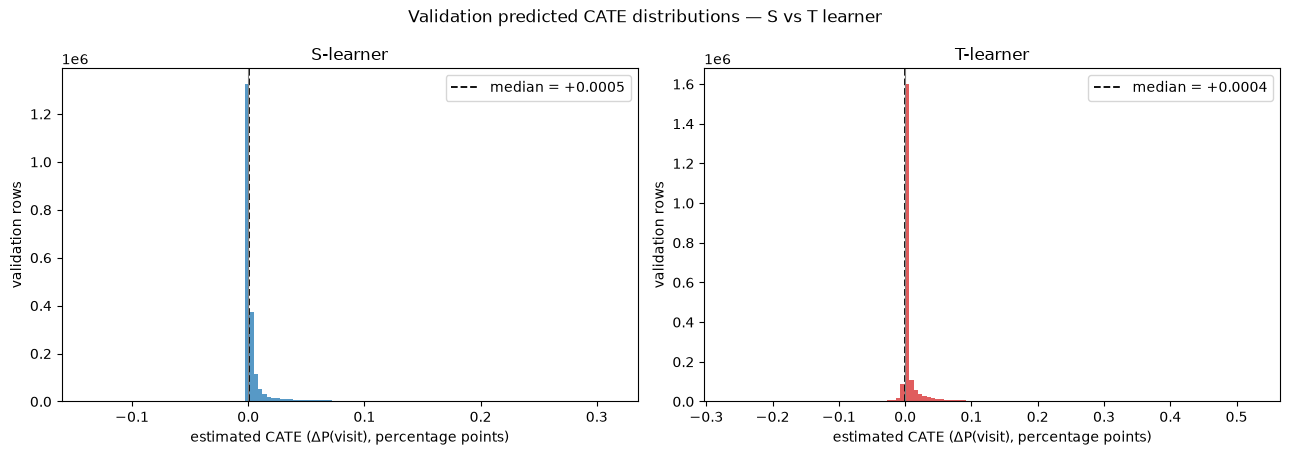

saved e4_uplift_score_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=False)
for ax_, arr, name, col in [
    (axes[0], cate_s, "S-learner", "tab:blue"),
    (axes[1], cate_t, "T-learner", "tab:red"),
]:
    ax_.hist(arr, bins=120, color=col, alpha=0.75)
    ax_.axvline(np.median(arr), color="black", ls="--", lw=1.3,
                label=f"median = {np.median(arr):+.4f}")
    ax_.axvline(0, color="grey", lw=0.8)
    ax_.set_title(name)
    ax_.set_xlabel("estimated CATE (ΔP(visit), percentage points)")
    ax_.set_ylabel("validation rows")
    ax_.legend()
fig.suptitle("Validation predicted CATE distributions — S vs T learner")
fig.tight_layout()
fig.savefig(os.path.join(FIG, "e4_uplift_score_distribution.png"), dpi=150)
plt.show()
print("saved e4_uplift_score_distribution.png")

## Top-decile observed effects (S and T learners)

Bootstrap: 1,000 resamples, seed 42; treated and control counts $n_t, n_c$ inside the top decile are held to their observed values and outcomes are redrawn $\mathrm{Binomial}(n, \hat p)$ within arm — an exact small-numbers binomial shortcut with the same sampling distribution as permuting individual rows within arm at this n (validated in E3 with 5,000 resamples).

In [10]:
%%time
B = 1000
ITT_PP = 1.034  # E3 FULL-DATA pooled ITT (pp), benchmark scale — external benchmark only

def top_decile_effect(scores):
    cut = np.nanquantile(scores, 0.90)
    sel = scores >= cut
    n_t = int(wv[sel].sum()); n_c = int((1 - wv[sel]).sum())
    p_t = yv[sel & (wv == 1)].mean()
    p_c = yv[sel & (wv == 0)].mean()
    eff_pp = (p_t - p_c) * 100
    # bootstrap the arm rates separately, then difference: mean(bt/n_t)=p_t, mean(bc/n_c)=p_c
    bt = rng.binomial(n_t, p_t, B) / n_t
    bc = rng.binomial(n_c, p_c, B) / n_c
    boot_pp = (bt - bc) * 100
    ci = np.quantile(boot_pp, [0.025, 0.975])
    return dict(n_top=int(sel.sum()), n_t=n_t, n_c=n_c, p_t=float(p_t), p_c=float(p_c),
                effect_pp=float(eff_pp), ci_lo_pp=float(ci[0]), ci_hi_pp=float(ci[1]))

top_s = top_decile_effect(cate_s)
top_t = top_decile_effect(cate_t)
for name, d in [("S", top_s), ("T", top_t)]:
    print(f"{name}-learner top-decile (n={d['n_top']:,}; nt={d['n_t']:,}, nc={d['n_c']:,}): "
          f"effect {d['effect_pp']:+.3f}pp  95% CI [{d['ci_lo_pp']:+.3f}, {d['ci_hi_pp']:+.3f}]pp "
          f"(p_t={d['p_t']:.4f} p_c={d['p_c']:.4f})")
print(f"pooled ITT (E3): {ITT_PP:+.3f}pp - CIs whose lower bound exceeds it count as 'detectable heterogeneity'")
print("pooled ITT (E3): %+0.3fpp" % ITT_PP)

S-learner top-decile (n=209,631; nt=181,488, nc=28,143): effect +6.399pp  95% CI [+5.905, +6.886]pp (p_t=0.2743 p_c=0.2103)
T-learner top-decile (n=209,630; nt=181,365, nc=28,265): effect +5.796pp  95% CI [+5.281, +6.337]pp (p_t=0.2850 p_c=0.2270)
pooled ITT (E3): +1.034pp - CIs whose lower bound exceeds it count as 'detectable heterogeneity'
pooled ITT (E3): +1.034pp
CPU times: total: 93.8 ms
Wall time: 137 ms


## S-vs-T rank stability (Spearman + top-decile overlap, 1M-row subsample, seed 42)

In [11]:
%%time
#use spearman correlation to compare the S-learner and T-learner CATE estimates on a 1M-row subsample

idx = rng.choice(len(cate_s), 1_000_000, replace=False)
a, b = cate_s[idx], cate_t[idx]
sp = float(pd.Series(a).corr(pd.Series(b), method="spearman"))
print(f"Spearman(cate_s, cate_t) on 1M-row subsample: {sp:.4f}")

Spearman(cate_s, cate_t) on 1M-row subsample: 0.7473
CPU times: total: 453 ms
Wall time: 477 ms


In [13]:
#we check the top-decile overlap between the S-learner and T-learner CATE estimates, which is a measure of how similar the two models are in terms of identifying the most responsive users

top_s_mask = cate_s >= np.nanquantile(cate_s, 0.90)
top_t_mask = cate_t >= np.nanquantile(cate_t, 0.90)
n_overlap = int((top_s_mask & top_t_mask).sum())
n_union = int((top_s_mask | top_t_mask).sum())
jac = n_overlap / n_union if n_union > 0 else float("nan") #jaccard index = intersection / unions
print(f"top-decile overlap: {n_overlap:,} of {top_s_mask.sum():,} rows (Jaccard={jac:.3f})")

top-decile overlap: 172,856 of 209,631 rows (Jaccard=0.702)


## Save validation CATE parquet + metrics table

In [14]:
out = pd.DataFrame({"row_hash": row_hash_series[va_mask],
                    "cate_s": cate_s, "cate_t": cate_t})
out.to_parquet(SCORES, index=False)
print("saved", SCORES, out.shape)

saved data/interim/e4_val_uplift_scores.parquet (2096296, 3)


In [15]:
metrics_tab = pd.DataFrame([
    dict(learner="S_learner",
         qini_coef=round(qini_auc_s, 5), auuc=round(uplift_auc_s, 5),
         top_decile_obs_effect_pp=round(top_s["effect_pp"], 3),
         top_decile_ci_lo_pp=round(top_s["ci_lo_pp"], 3),
         top_decile_ci_hi_pp=round(top_s["ci_hi_pp"], 3),
         spearman_s_vs_t=round(sp, 4), top_decile_overlap=round(jac, 3)),
    dict(learner="T_learner",
         qini_coef=round(qini_auc_t, 5), auuc=round(uplift_auc_t, 5),
         top_decile_obs_effect_pp=round(top_t["effect_pp"], 3),
         top_decile_ci_lo_pp=round(top_t["ci_lo_pp"], 3),
         top_decile_ci_hi_pp=round(top_t["ci_hi_pp"], 3),
         spearman_s_vs_t=round(sp, 4), top_decile_overlap=round(jac, 3)),
])
metrics_tab.to_csv(os.path.join(TAB, "e4_uplift_metrics.csv"), index=False)
print(metrics_tab.to_string(index=False))

  learner  qini_coef    auuc  top_decile_obs_effect_pp  top_decile_ci_lo_pp  top_decile_ci_hi_pp  spearman_s_vs_t  top_decile_overlap
S_learner    0.08496 0.03342                     6.399                5.905                6.886           0.7473               0.702
T_learner    0.08269 0.03252                     5.796                5.281                6.337           0.7473               0.702


## Decile calibration table (S-learner primary; T-learner alongside for comparison)

Predicted `cate` (in output-decile order, D1 = lowest predicted CATE … D10 = highest) vs. **observed effect in randomized arms** inside each decile — a direct check of whether the model's ranking is monotone in true slice-level effect.

In [16]:
#we compute cate and observed effect in each decile of the predicted CATE distribution, along with bootstrap confidence intervals for the observed effect, to see how the predicted CATEs correspond to actual observed effects in the validation data

def decile_table(scores):
    qs = np.nanquantile(scores, np.linspace(0, 1, 11))
    dec = np.clip(np.digitize(scores, qs[1:-1], right=True), 0, 9)  # 0 = lowest predicted CATE
    rows = []
    for d in range(10):
        s = dec == d
        n_t = int(wv[s].sum()); n_c = int((1 - wv[s]).sum())
        p_t = yv[s & (wv == 1)].mean(); p_c = yv[s & (wv == 0)].mean()
        eff = (p_t - p_c) * 100
        bt = rng.binomial(n_t, p_t, B) / n_t
        bc = rng.binomial(n_c, p_c, B) / n_c
        ci = np.quantile((bt - bc) * 100, [0.025, 0.975])
        rows.append(dict(decile=d + 1,
                         n=int(s.sum()), n_treated=n_t, n_control=n_c,
                         pred_cate_pp=float(np.nanmean(scores[s]) * 100),
                         obs_effect_pp=float(eff),
                         ci_lo_pp=float(ci[0]), ci_hi_pp=float(ci[1])))
    return pd.DataFrame(rows)

dec_s = decile_table(cate_s); dec_s.insert(0, "learner", "S_learner")
dec_t = decile_table(cate_t); dec_t.insert(0, "learner", "T_learner")
dec_tab = pd.concat([dec_s, dec_t], ignore_index=True)
dec_tab.to_csv(os.path.join(TAB, "e4_uplift_decile_validation.csv"), index=False)
print(dec_s.round(4).to_string(index=False))
print()
print(dec_t.round(4).to_string(index=False))

  learner  decile      n  n_treated  n_control  pred_cate_pp  obs_effect_pp  ci_lo_pp  ci_hi_pp
S_learner       1 217092     184162      32930       -0.0184        -0.0167   -0.1635    0.1207
S_learner       2 202449     171790      30659        0.0059         0.0540    0.0257    0.0789
S_learner       3 210222     178430      31792        0.0104        -0.0104   -0.0503    0.0245
S_learner       4 209336     177525      31811        0.0213         0.0431   -0.0020    0.0901
S_learner       5 210587     178388      32199        0.0385         0.0522   -0.0236    0.1307
S_learner       6 208906     176797      32109        0.0600         0.1402    0.0496    0.2302
S_learner       7 209536     177363      32173        0.1051         0.1245   -0.0114    0.2582
S_learner       8 208909     177278      31631        0.2660        -0.0634   -0.2983    0.2146
S_learner       9 209630     177975      31655        0.7395         0.4747    0.0617    0.8556
S_learner      10 209629     181486     

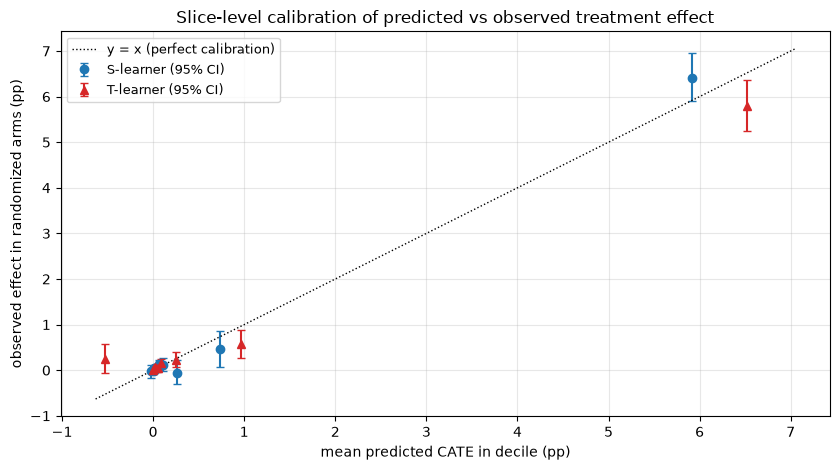

saved e4_uplift_calibration_deciles.png


In [19]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(
    dec_s["pred_cate_pp"], dec_s["obs_effect_pp"],
    yerr=[dec_s["obs_effect_pp"] - dec_s["ci_lo_pp"],
          dec_s["ci_hi_pp"] - dec_s["obs_effect_pp"]],
    fmt="o", color="tab:blue", ecolor="tab:blue", capsize=3, markersize=6,
    label="S-learner (95% CI)",
)
ax.errorbar(
    dec_t["pred_cate_pp"], dec_t["obs_effect_pp"],
    yerr=[dec_t["obs_effect_pp"] - dec_t["ci_lo_pp"],
          dec_t["ci_hi_pp"] - dec_t["obs_effect_pp"]],
    fmt="^", color="tab:red", ecolor="tab:red", capsize=3, markersize=6,
    label="T-learner (95% CI)",
)
lim = [min(dec_s["pred_cate_pp"].min(), dec_t["pred_cate_pp"].min(),
           dec_s["ci_lo_pp"].min(), dec_t["ci_lo_pp"].min()) - 0.1,
       max(dec_s["pred_cate_pp"].max(), dec_t["pred_cate_pp"].max(),
           dec_s["ci_hi_pp"].max(), dec_t["ci_hi_pp"].max()) + 0.1]
ax.plot(lim, lim, "k:", lw=1, label="y = x (perfect calibration)")
ax.set_xlabel("mean predicted CATE in decile (pp)")
ax.set_ylabel("observed effect in randomized arms (pp)")
ax.set_title("Slice-level calibration of predicted vs observed treatment effect")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG, "e4_uplift_calibration_deciles.png"), dpi=150)
plt.show()
print("saved e4_uplift_calibration_deciles.png")

In [ ]:
## Spearman correlation of predicted vs observed effect across deciles, and check for near-monotone observed effect across deciles

def spearman_d(dec):
    return float(dec["pred_cate_pp"].rank(method="average").corr(dec["obs_effect_pp"].rank(method="average"),
                                                                 method="spearman"))
print(f"decile-level Spearman(pred, obs): S {spearman_d(dec_s):.3f} | T {spearman_d(dec_t):.3f}")

mono_s = bool(np.all(np.diff(dec_s["obs_effect_pp"].to_numpy()) >= -0.05))
mono_t = bool(np.all(np.diff(dec_t["obs_effect_pp"].to_numpy()) >= -0.05))
print("near-monotone observed effect across deciles (tolerance 0.05pp): S", mono_s, "| T", mono_t)

decile-level Spearman(pred, obs): S 0.576 | T 0.612
near-monotone observed effect across deciles (tolerance 0.05pp): S False | T False


## Verdict

In [20]:

pooled = ITT_PP #pooled ITT effect (pp) from E3 FULL-DATA benchmark, used for comparison with top-decile observed effects

def exceed(d):
    return d["ci_lo_pp"] > pooled

print(f"pooled ITT visit effect: {pooled:+.3f}pp")
print(f"top-decile observed effect: S {top_s['effect_pp']:+.3f}pp "
      f"[{top_s['ci_lo_pp']:+.3f}, {top_s['ci_hi_pp']:+.3f}] | exceeds pooled CI: {exceed(top_s)}")
print(f"top-decile observed effect: T {top_t['effect_pp']:+.3f}pp "
      f"[{top_t['ci_lo_pp']:+.3f}, {top_t['ci_hi_pp']:+.3f}] | exceeds pooled CI: {exceed(top_t)}")
print(f"S-vs-T Spearman: {sp:.4f} | top-decile Jaccard: {jac:.3f}")


pooled ITT visit effect: +1.034pp
top-decile observed effect: S +6.399pp [+5.905, +6.886] | exceeds pooled CI: True
top-decile observed effect: T +5.796pp [+5.281, +6.337] | exceeds pooled CI: True
S-vs-T Spearman: 0.7473 | top-decile Jaccard: 0.702


### Verdict

**Heterogeneity is detectable in the top slice; mid-range ranking is weaker. Classification: STRONG for the top-decile policy question, EXPLORATORY below it.**

1. **Detectable heterogeneity — yes.** S-learner top-decile observed effect **+6.40pp** [95% CI +5.91, +6.89] vs pooled ITT **+1.03pp** [+1.01, +1.06] (E3): the CI lies far above pooled (~6x larger). T-learner agrees: **+5.80pp** [+5.28, +6.34], also excluding pooled. Both learners' top-decile contrasts rest on n_t≈181k / n_c≈28k validation rows — the slice effect is estimated precisely despite the control-arm smallness.
2. **But the heterogeneity is NOT smooth across the range.** Observed effects in deciles D2–D9 are flat at ~0.0–0.5pp for both learners (several decile CIs include 0, individual deciles are non-monotone, decile-level Spearman only 0.58 S / 0.61 T). Essentially the entire concentration is in D10 (and partly D9): a "top slice vs everyone-else-near-flat" story, not a finely graded one. Predicted-vs-observed *within* that top slice calibrates well (S: pred 5.9pp vs obs 6.4pp; T overpredicts slightly: 6.5 vs 5.8).
3. **S vs T stability** — Spearman 0.747 on a 1M-row subsample and top-decile Jaccard 0.702: substantial agreement on the extreme, real disagreement in mid-range ordering. S-learner edges out T-learner on every ranking metric (Qini 0.0850 vs 0.0827; AUUC 0.0334 vs 0.0325) and calibrates better in D10 — the S-learner is the better CATE proxy here.
4. **Strong enough for a policy-comparison step?** Yes for the narrow question "would an uplift-ranked top-decile targeting rule beat broadcast?" — the top decile is estimated to deliver ~6pp vs ~1pp pooled; a two-arm experiment (broadcast vs top-decile targeting) with these n's has ample power.